# 3 · Franklin dataset (no derivatisation)

In [1]:
import os, sys, subprocess
from pathlib import Path

sys.path.insert(0, os.path.abspath(".."))

from src.workflow.job_submission import (
    submit_slurm_array, submit_qcxms_frag_jobs, run_plotms_for_included,
    submit_crest_jobs, submit_qcxms2_jobs, submit_cfmid_job,
    write_cfmid_idx_smiles, check_crest_status,
)
from src.processing.process_spectra_batch import process_spectra_batch
from src.analysis.run_comparison import run_comparison
from src.analysis.diagnose_spectra import diagnose_spectra

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CONFIG                                                                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝

DATASET_NAME = "franklin"
RAW_CSV      = "../data/raw/franklin/goamazon.csv"
DERIVATIZE   = False

RUN_QCXMS  =  True
RUN_QCXMS2 = True
RUN_QCXMS2_DFT = False
RUN_NEIMS  = True
RUN_CFMID  =  True
FORCE_FRAG =  True
QCXMS_VARIANTS = ["QCxMS_10_ps", "QCxMS_25_ps", "QCxMS_10_ps_iee03"]

# Specific array specs used on the original run (override if re-running subset)
GSMD_ARRAY_SPECS = {
    "QCxMS_10_ps":       "0044,0030,0014,0007",
    "QCxMS_25_ps":       "0047,0044,0005,0014",
    "QCxMS_10_ps_iee03": "52-61",
}

SMILES_COLUMN = "SMILES"
N_MOLS = None  # auto-detected

# Molecules where CREST gets stuck — update after checking status in section 3
# Example: CREST_STUCK_FOLDERS = ["0000", "0013", "0022", "0034", "0035", "0036", "0048", "0056"]
CREST_STUCK_FOLDERS = []

# ── Compile-only mode ────────────────────────────────────────────────────────
# True  → skip all job submission; only run spectrum processing, diagnostics,
#         and spectral comparison (sections 7–9).
COMPILE_ONLY = True

# Methods to include in processing, diagnostics, and comparison.
# None → determined by RUN_* flags above.
# Set to a list to analyse a subset without changing RUN_* flags, e.g.:
#   ["QCxMS_25_ps", "QCxMS2", "NEIMS", "CFMID"]
COMPILE_METHODS = ["QCxMS_10_ps", "QCxMS2", "NEIMS", "CFMID"]

In [3]:
# ── Derived paths — no editing needed ──────────────────────────────────────
SRC_ROOT  = os.path.abspath("../src")
DATA_ROOT = os.path.abspath("../data")

PROCESSED_DIR = f"{DATA_ROOT}/processed/{DATASET_NAME}"
SIM_BASE      = f"{DATA_ROOT}/simulation_results/{DATASET_NAME}"

INPUT_CSV      = (f"{PROCESSED_DIR}/{DATASET_NAME}_TMS.csv"
                  if DERIVATIZE else f"{PROCESSED_DIR}/dataset_unique.csv")
SMILES_COL_SIM = "Modified_SMILES" if DERIVATIZE else SMILES_COLUMN

METHODS = (
    (QCXMS_VARIANTS             if RUN_QCXMS      else [])
  + (["QCxMS2"]                 if RUN_QCXMS2     else [])
  + (["QCxMS2_dft"]             if RUN_QCXMS2_DFT else [])
  + (["NEIMS"]                  if RUN_NEIMS       else [])
  + (["CFMID"]                  if RUN_CFMID       else [])
)

# Effective methods for spectrum processing, diagnostics, and comparison
_effective_methods = COMPILE_METHODS if COMPILE_METHODS is not None else METHODS

# Auto-detect molecule count from processed CSV
import pandas as pd
if N_MOLS is None and os.path.exists(INPUT_CSV):
    N_MOLS = len(pd.read_csv(INPUT_CSV))

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(SIM_BASE,      exist_ok=True)

print(f"Dataset:      {DATASET_NAME}")
print(f"Derivatize:   {DERIVATIZE}")
print(f"Input CSV:    {INPUT_CSV}  (exists: {os.path.exists(INPUT_CSV)})")
print(f"Sim base:     {SIM_BASE}")
print(f"N_MOLS:       {N_MOLS}")
print(f"Compile-only: {COMPILE_ONLY}")
print(f"Methods:      {_effective_methods}")

Dataset:      franklin
Derivatize:   False
Input CSV:    /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/processed/franklin/dataset_unique.csv  (exists: True)
Sim base:     /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin
N_MOLS:       61
Compile-only: True
Methods:      ['QCxMS_10_ps', 'QCxMS2', 'NEIMS', 'CFMID']


## 1. Data preparation

In [4]:
!python {SRC_ROOT}/processing/remove_duplicate_SMILES_entries.py \
    -i  {RAW_CSV} \
    -o  {PROCESSED_DIR}/dataset_unique.csv \
    --index_map_file {PROCESSED_DIR}/duplicate_mapping.csv \
    --log_file       {PROCESSED_DIR}/dataset_duplicates.csv

Saved 61 unique molecules to /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/processed/franklin/dataset_unique.csv
Saved duplicate mapping to /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/processed/franklin/dataset_duplicates.csv
Saved old->new index mapping to /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/processed/franklin/duplicate_mapping.csv


In [5]:
if DERIVATIZE:
    !python {SRC_ROOT}/processing/make_TMS_derivative_251125_v1.py --compare_ref \
        -i {PROCESSED_DIR}/dataset_unique.csv \
        -o {INPUT_CSV}
else:
    print("DERIVATIZE=False — using dataset_unique.csv as INPUT_CSV.")

# Re-detect N_MOLS now that the processed CSV exists
if N_MOLS is None:
    N_MOLS = len(pd.read_csv(INPUT_CSV))
    print(f"N_MOLS = {N_MOLS}")

DERIVATIZE=False — using dataset_unique.csv as INPUT_CSV.


## 2. QCxMS — directory setup, GS-MD, fragmentation & PlotMS

In [6]:
if RUN_QCXMS and not COMPILE_ONLY:
    for variant in QCXMS_VARIANTS:
        !python {SRC_ROOT}/processing/make_directories_and_sdfs.py \
            --input_csv   {INPUT_CSV} \
            --output_root {SIM_BASE}/{variant}

In [7]:
if RUN_QCXMS and not COMPILE_ONLY:
    GSMD_SCRIPTS = {
        "QCxMS_10_ps":       "submit_qcxms_gs_md_10_ps.sh",
        "QCxMS_25_ps":       "submit_qcxms_gs_md_25_ps.sh",
        "QCxMS_10_ps_iee03": "submit_qcxms_gs_md_10_ps_iee03.sh",
    }
    for variant in QCXMS_VARIANTS:
        print(f"\n--- {variant} ---")
        submit_slurm_array(
            sim_dir     = f"{SIM_BASE}/{variant}",
            script_path = f"{SRC_ROOT}/workflow/{GSMD_SCRIPTS[variant]}",
            array_spec  = GSMD_ARRAY_SPECS.get(variant, f"0-{N_MOLS - 1}"),
            done_marker = "GS-opt/MS-run/TMPQCXMS",
            n_mols      = N_MOLS,
        )

In [8]:
if RUN_QCXMS and not COMPILE_ONLY:
    FRAG_SCRIPTS = {
        "QCxMS_10_ps":       "submit_qcxms_frag_serial_no_unity.sh",
        "QCxMS_25_ps":       "submit_qcxms_frag_serial_no_unity.sh",
        "QCxMS_10_ps_iee03": "submit_qcxms_frag_serial_no_unity_iee03.sh",
    }
    for variant in QCXMS_VARIANTS:
        print(f"\n--- {variant} ---")
        submit_qcxms_frag_jobs(
            sim_dir     = f"{SIM_BASE}/{variant}",
            script_path = os.path.abspath(f"{SRC_ROOT}/workflow/{FRAG_SCRIPTS[variant]}"),
            n_mols      = N_MOLS,
            skip_done_check = FORCE_FRAG,
        )

In [9]:
# Check how many trajectories finished (reads stdout of check_qcxms_runs.sh)
if RUN_QCXMS:
    check_script = os.path.abspath(f"{SRC_ROOT}/utils/check_qcxms_runs.sh")
    for variant in QCXMS_VARIANTS:
        print(f"\n=== {variant} ===")
        subprocess.run(["sh", check_script], cwd=f"{SIM_BASE}/{variant}")


=== QCxMS_10_ps ===

=== QCxMS_25_ps ===

=== QCxMS_10_ps_iee03 ===


In [10]:
# Run PlotMS for all INCLUDE molecules (requires analysis_decision.txt)
if RUN_QCXMS:
    for variant in QCXMS_VARIANTS:
        print(f"\n--- {variant} ---")
        run_plotms_for_included(wrkdir=f"{SIM_BASE}/{variant}")


--- QCxMS_10_ps ---
Folders to process (4): ['0008', '0019', '0035', '0036']
[REDO] 0008: prior run below quality (1967 runs, base peak 48) — re-running
[SKIP] 0008: TMPQCXMS archived but no valid plotms.res — skipping PlotMS
[SKIP] 0019: already done (1516 runs, base peak 102) [TMPQCXMS archived]
[SKIP] 0035: already done (1336 runs, base peak 135) [TMPQCXMS archived]
[REDO] 0036: prior run below quality (1767 runs, base peak 58) — re-running
[SKIP] 0036: TMPQCXMS archived but no valid plotms.res — skipping PlotMS

--- QCxMS_25_ps ---
Folders to process (10): ['0000', '0004', '0008', '0009', '0013', '0015', '0030', '0034', '0035', '0036']
[SKIP] 0000: already done (1298 runs, base peak 122) [TMPQCXMS archived]
[SKIP] 0004: already done (1195 runs, base peak 125) [TMPQCXMS archived]
[REDO] 0008: prior run below quality (1971 runs, base peak 28) — re-running
[SKIP] 0008: TMPQCXMS archived but no valid plotms.res — skipping PlotMS
[SKIP] 0009: already done (1912 runs, base peak 112) [TM

## 3. QCxMS2 — CREST conformer search & fragmentation

In [11]:
if RUN_QCXMS2 and not COMPILE_ONLY:
    !python {SRC_ROOT}/processing/make_directories_and_sdfs.py \
        --input_csv   {INPUT_CSV} \
        --output_root {SIM_BASE}/QCxMS2

In [12]:
if RUN_QCXMS2 and not COMPILE_ONLY:
    folders = CREST_STUCK_FOLDERS if CREST_STUCK_FOLDERS else [
        f"{i:04d}" for i in range(N_MOLS)
    ]
    submit_crest_jobs(
        sim_dir     = f"{SIM_BASE}/QCxMS2",
        script_path = os.path.abspath(f"{SRC_ROOT}/workflow/submit_batch_crest.sh"),
        folders     = folders,
    )

In [13]:
# Check CREST status — run after jobs finish.
# Copy any "Not done/stuck" IDs into CREST_STUCK_FOLDERS in CONFIG, then
# re-run the submission cell above.
if RUN_QCXMS2:
    check_crest_status({DATASET_NAME: f"{SIM_BASE}/QCxMS2"})


Dataset: franklin
  Finished:        57 — ['0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0023', '0024', '0025', '0026', '0027', '0028', '0029', '0031', '0032', '0033', '0035', '0036', '0037', '0038', '0039', '0040', '0041', '0042', '0043', '0045', '0046', '0047', '0048', '0049', '0050', '0051', '0052', '0053', '0054', '0055', '0056', '0057', '0058', '0059', '0060']
  Still running:    1 — ['0034']
  Not done/stuck:   3 — ['0022', '0030', '0044']
  Missing dir:      0 — []


In [14]:
if RUN_QCXMS2 and not COMPILE_ONLY:
    submit_qcxms2_jobs(
        base_dir    = f"{SIM_BASE}/QCxMS2",
        bash_script = os.path.abspath(f"{SRC_ROOT}/workflow/submit_qcxms2_job.sh"),
        num_folders = N_MOLS,
    )

## 3b. QCxMS2_dft — wB97X-3c refinement

Uses the same CREST conformer output as QCxMS2, with recommended mixed-level settings:
GFN2-xTB for geometry and IP prescreening; wB97X-3c for barriers and IP refinement.

In [15]:
if RUN_QCXMS2_DFT and not COMPILE_ONLY:
    from src.workflow.job_submission import submit_qcxms2_jobs
    import shutil
    dft_base = f"{SIM_BASE}/QCxMS2_dft"
    qcxms2_base = f"{SIM_BASE}/QCxMS2"
    # Set up mol dirs and copy crest_best.xyz from QCxMS2
    for mol_id in [f"{i:04d}" for i in range(N_MOLS)]:
        src_xyz = Path(qcxms2_base) / mol_id / "crest_best.xyz"
        dst_dir = Path(dft_base) / mol_id
        if not src_xyz.exists():
            continue
        dst_dir.mkdir(parents=True, exist_ok=True)
        if not (dst_dir / "crest_best.xyz").exists():
            shutil.copy2(src_xyz, dst_dir / "crest_best.xyz")
        for log in ("crest.log", "crest_restart.log"):
            src_log = Path(qcxms2_base) / mol_id / log
            if src_log.exists() and not (dst_dir / log).exists():
                shutil.copy2(src_log, dst_dir / log)
    submit_qcxms2_jobs(
        base_dir       = dft_base,
        bash_script    = os.path.abspath(f"{SRC_ROOT}/workflow/submit_qcxms2_dft_job.sh"),
        method         = "wb97x3c",
        num_folders    = N_MOLS,
    )

## 4. NEIMS

In [16]:
if RUN_NEIMS and not COMPILE_ONLY:
    !python {SRC_ROOT}/processing/make_directories_and_sdfs.py \
        --input_csv   {INPUT_CSV} \
        --output_root {SIM_BASE}/NEIMS
    submit_slurm_array(
        sim_dir     = f"{SIM_BASE}/NEIMS",
        script_path = f"{SRC_ROOT}/workflow/submit_neims_array.sh",
        array_spec  = f"0-{N_MOLS - 1}",
        done_marker = "annotated.sdf",
        n_mols      = N_MOLS,
    )

## 5. CFMID

In [17]:
if RUN_CFMID and not COMPILE_ONLY:
    !python {SRC_ROOT}/processing/make_directories_and_sdfs.py \
        --input_csv   {INPUT_CSV} \
        --output_root {SIM_BASE}/CFMID
    submit_cfmid_job(
        cfmid_dir   = f"{SIM_BASE}/CFMID",
        script_path = os.path.abspath(f"{SRC_ROOT}/workflow/run_cfmid.sh"),
        n_mols      = N_MOLS,
    )
    write_cfmid_idx_smiles(f"{SIM_BASE}/CFMID")

## 6. Experimental spectra

In [18]:
if not COMPILE_ONLY:
    subprocess.run([
        "python", f"{SRC_ROOT}/processing/make_inchlkey_sdf_for_nist.py",
        "--input_csv",     INPUT_CSV,
        "--smiles_column", SMILES_COL_SIM,
        "--output_root",   f"{SIM_BASE}/EXP/",
    ])

## 7. Spectrum processing

In [19]:
process_spectra_batch(SIM_BASE, _effective_methods + ["EXP"])

Simulation base directory: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin
Processing script:         /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/processing/bin_scale_intensities.py
Override existing:         False

  [QCxMS_10_ps/0014] Input not found: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin/QCxMS_10_ps/0014/GS-opt/MS-run/result.csv
  [QCxMS_10_ps/0044] Input not found: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin/QCxMS_10_ps/0044/GS-opt/MS-run/result.csv
[QCxMS_10_ps] processed=0  skipped=59  missing_input=2
  [QCxMS2/0008] Input not found: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin/QCxMS2/0008/qcxms2_gfn2/peaks.csv
  [QCxMS2/0009] Input not found: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results

## 8. Diagnostics — spectra coverage


═════════════════════════════════════════════════════════════════
  Spectra diagnostics — franklin
═════════════════════════════════════════════════════════════════
  Method                       Complete  Missing  No dir       %
  ──────────────────────────── ──────── ──────── ───────  ──────
  QCxMS_10_ps                        59        2       0   96.7%
  QCxMS2                             46       15       0   75.4%
  NEIMS                              61        0       0  100.0%  ✓
  CFMID                              61        0       0  100.0%  ✓
  EXP                                51       10       0   83.6%
  ──────────────────────────── ──────── ──────── ───────  ──────
  Total molecules expected: 61

─────────────────────────────────────────────────────────────────
  Missing molecules per method:
─────────────────────────────────────────────────────────────────
  QCxMS_10_ps                 : 0014, 0044
  QCxMS2                      : 0008, 0009, 0013, 0014, 0015, 0018, 0

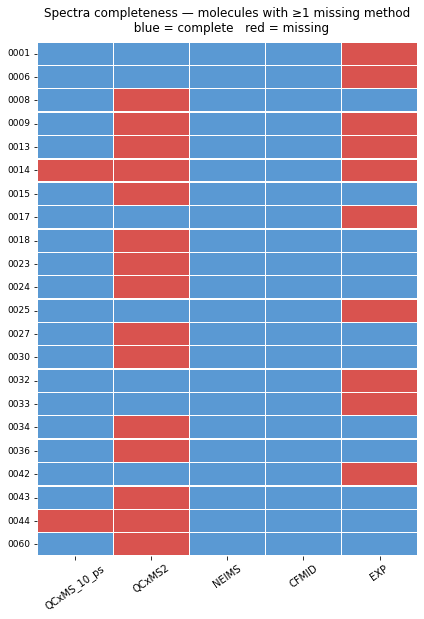

In [20]:
diag = diagnose_spectra(SIM_BASE, _effective_methods + ["EXP"], n_mols=N_MOLS,
                        output_dir=os.path.abspath(f"../reports/{DATASET_NAME}/paper"))

## 9. Spectral comparison

In [21]:
run_comparison(SIM_BASE, _effective_methods)

Simulation base directory: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin
Comparison script:         /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/analysis/compare_spectra.py
Methods:                   ['QCxMS_10_ps', 'QCxMS2', 'NEIMS', 'CFMID']
Comparison complete.
[0000/all] REF=/scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin/EXP/0000/spectra/spectra_all.csv  SIM=/scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin/QCxMS_10_ps/0000/spectra/spectra_all.csv
[0000/all] REF=/scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin/EXP/0000/spectra/spectra_all.csv  SIM=/scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin/QCxMS2/0000/spectra/spectra_all.csv
[0000/all] REF=/scratch/project_2006752/hsandstr/Project/atmospheric-ms-

Found 61 molecule result dirs in /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin/results
Done — updated 159 Entropy_Similarity values in /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin



## 9b. Entropy similarity — manual patch (optional)

`run_comparison()` (section 9) now calls `patch_entropy.py` automatically
using the system Python 3.8 after each comparison run, so entropy values
are filled without any extra steps.

Run this cell only if you ran `compare_spectra.py` directly and skipped
`run_comparison()`, or if you want to force-recompute entropy values.

In [22]:
# Back-fill Entropy_Similarity using system Python 3.8 (ms_entropy 1.5.1).
# run_comparison() now calls this automatically — only needed if you
# ran compare_spectra.py directly or want to force a recompute.
import subprocess
subprocess.run([
    '/appl/opt/python/3.8.14-gnu850/bin/python3.8',
    f'{SRC_ROOT}/analysis/patch_entropy.py',
    '--base_dir', 'data/simulation_results/franklin',
], check=True)

CompletedProcess(args=['/appl/opt/python/3.8.14-gnu850/bin/python3.8', '/scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/analysis/patch_entropy.py', '--base_dir', 'data/simulation_results/franklin'], returncode=0)